In [2]:
import pandas as pd
import numpy as np

# Load NAV data
nav = pd.read_csv("../data/processed/02_nav_history.csv")

# Convert date to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Check the data
print(nav.head())
print(nav.columns)
print(nav.info())

   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474
2     119551 2022-01-05  54.6869
3     119551 2022-01-06  55.4550
4     119551 2022-01-07  55.3692
Index(['amfi_code', 'date', 'nav'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB
None


In [ ]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

print(nav.dtypes)

In [ ]:
print("Number of schemes:", nav["amfi_code"].nunique())

print("\nAMFI codes:")
print(nav["amfi_code"].unique())

print("\nNAV date range:")
print("Start:", nav["date"].min())
print("End:", nav["date"].max())

print("\nNAV missing values:")
print(nav.isnull().sum())

print("\nDuplicate NAV rows:", nav.duplicated().sum())

In [3]:
# Sort data by fund and date
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily returns for each fund
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Remove missing returns
returns = nav.dropna(subset=["daily_return"]).copy()

print("Returns data:", returns.shape)
print(returns[["amfi_code", "date", "daily_return"]].head())

Returns data: (45960, 4)
      amfi_code       date  daily_return
5751     100016 2022-01-04     -0.010306
5752     100016 2022-01-05      0.012865
5753     100016 2022-01-06     -0.011377
5754     100016 2022-01-07     -0.001210
5755     100016 2022-01-10     -0.008639


In [ ]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

print(nav[["amfi_code", "date", "nav", "daily_return"]].head(10))

In [4]:
# Calculate Historical VaR (95%) and CVaR for each fund

var_results = []

for fund, group in returns.groupby("amfi_code"):
    fund_returns = group["daily_return"].dropna()

    # 5th percentile = 95% Historical VaR threshold
    var_95 = fund_returns.quantile(0.05)

    # CVaR = average return below VaR threshold
    cvar_95 = fund_returns[fund_returns <= var_95].mean()

    var_results.append({
        "amfi_code": fund,
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

var_df = pd.DataFrame(var_results)

print("VaR/CVaR results:", var_df.shape)
print(var_df.head())

VaR/CVaR results: (40, 3)
   amfi_code    VaR_95   CVaR_95
0     100016 -0.014364 -0.018060
1     100025 -0.003793 -0.004994
2     100033 -0.019034 -0.023456
3     101206 -0.013282 -0.017439
4     101207 -0.026021 -0.032459


In [ ]:
nav = pd.read_csv("../data/processed/02_nav_history.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

print("NAV loaded:", nav.shape)
print("Benchmark loaded:", benchmark.shape)

In [5]:
# Save VaR and CVaR results
var_df.to_csv("../reports/var_cvar_95.csv", index=False)

print("Saved: reports/var_cvar_95.csv")

Saved: reports/var_cvar_95.csv


In [ ]:
sharpe_results = []

for amfi_code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()

    excess_returns = returns - daily_rf

    sharpe = (
        excess_returns.mean() / returns.std()
    ) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": amfi_code,
        "Sharpe_Ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

print(sharpe_df)

In [6]:
# Calculate 90-day rolling Sharpe Ratio for each fund

returns["rolling_sharpe_90"] = (
    returns.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).mean() /
               x.rolling(90).std() * np.sqrt(252))
)

print(returns[["amfi_code", "date", "rolling_sharpe_90"]].tail())

       amfi_code       date  rolling_sharpe_90
45995     149324 2026-05-25           2.042795
45996     149324 2026-05-26           2.064950
45997     149324 2026-05-27           1.952646
45998     149324 2026-05-28           1.406239
45999     149324 2026-05-29           1.262776


In [ ]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

print(nav[["amfi_code", "date", "nav", "daily_return"]].head(10))

In [7]:
# Select 5 funds for visualization
key_funds = returns["amfi_code"].drop_duplicates().head(5).tolist()

print("Selected funds:", key_funds)

Selected funds: [100016, 100025, 100033, 101206, 101207]


In [ ]:
sharpe_df["Sharpe_Rank"] = (
    sharpe_df["Sharpe_Ratio"]
    .rank(ascending=False, method="min")
)

sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
).reset_index(drop=True)

print(sharpe_df.to_string(index=False))

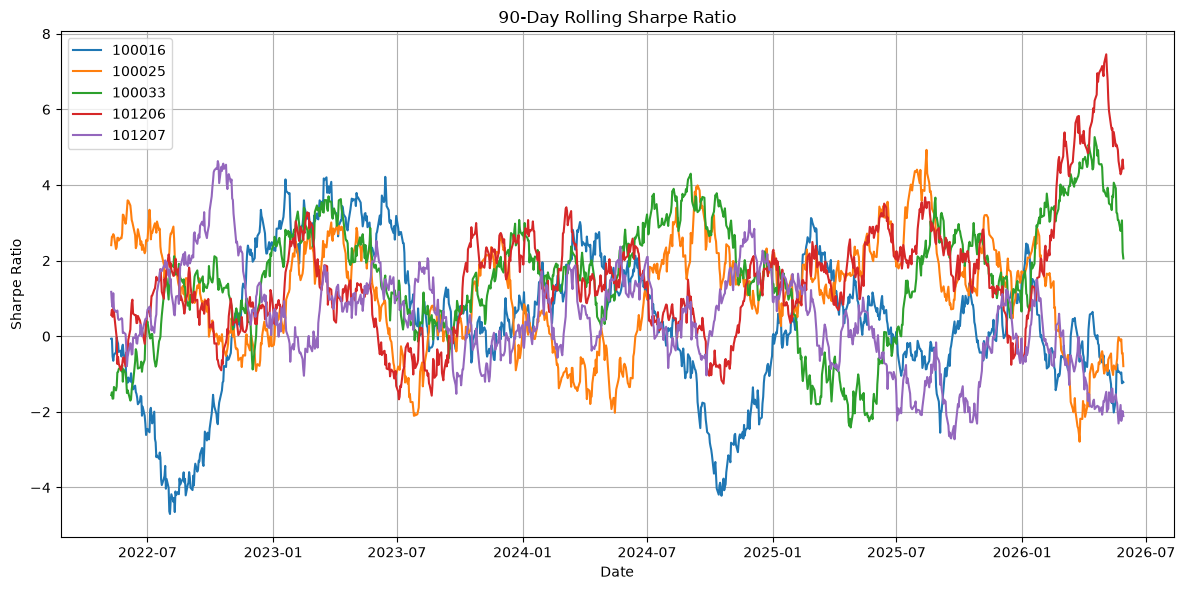

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for fund in key_funds:
    fund_data = returns[returns["amfi_code"] == fund]
    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe_90"],
        label=str(fund)
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("../reports/rolling_90_day_sharpe.png")
plt.show()

In [ ]:
print("Number of schemes:", nav["amfi_code"].nunique())

print("\nAMFI codes:")
print(nav["amfi_code"].unique())

print("\nNAV date range:")
print("Start:", nav["date"].min())
print("End:", nav["date"].max())

print("\nNAV missing values:")
print(nav.isnull().sum())

print("\nDuplicate NAV rows:", nav.duplicated().sum())

In [9]:
# Load investor transaction data

transactions = pd.read_csv(
    "../data/processed/08_investor_transactions.csv"
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

print("Transactions shape:", transactions.shape)
print(transactions.columns)
print(transactions.head())

Transactions shape: (32778, 13)
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male           

In [ ]:
RF = 0.065

daily_rf = (1 + RF) ** (1 / 252) - 1

print("Annual risk-free rate:", RF)
print("Daily risk-free rate:", daily_rf)

In [10]:
print(transactions.info())
print(transactions["transaction_type"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   investor_id         32778 non-null  str           
 1   transaction_date    32778 non-null  datetime64[us]
 2   amfi_code           32778 non-null  int64         
 3   transaction_type    32778 non-null  str           
 4   amount_inr          32778 non-null  int64         
 5   state               32778 non-null  str           
 6   city                32778 non-null  str           
 7   city_tier           32778 non-null  str           
 8   age_group           32778 non-null  str           
 9   gender              32778 non-null  str           
 10  annual_income_lakh  32778 non-null  float64       
 11  payment_mode        32778 non-null  str           
 12  kyc_status          32778 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(9)
memory

In [11]:
print(nav["daily_return"].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [15]:
# Annual risk-free rate
annual_rf = 0.065

# Convert annual risk-free rate to daily rate
daily_rf = (1 + annual_rf) ** (1 / 252) - 1

print("Daily risk-free rate:", daily_rf)

Daily risk-free rate: 0.00024993122427763304


In [16]:
sharpe_results = []

for amfi_code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()

    excess_returns = returns - daily_rf

    sharpe = (
        excess_returns.mean() / returns.std()
    ) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": amfi_code,
        "Sharpe_Ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

print(sharpe_df)

    amfi_code  Sharpe_Ratio
0      100016     -0.187650
1      100025     -0.515438
2      100033      1.104352
3      101206      1.041061
4      101207      0.170481
5      101208     -0.417229
6      102885      0.832815
7      102886     -0.194707
8      102887      0.632319
9      118632      1.095918
10     118633      0.659620
11     118634      0.456426
12     118635      0.680395
13     118636     -0.306013
14     119092      0.045245
15     119093      0.144041
16     119094      1.008626
17     119095     -0.067926
18     119120     -0.175723
19     119551      1.222947
20     119552      0.967752
21     119598      0.953332
22     119599     -0.049101
23     120503      0.812502
24     120504      1.040569
25     120505      1.190559
26     120506      0.662124
27     120507      0.904162
28     120841      0.509256
29     120842      0.087273
30     120843      1.319442
31     120844      0.304252
32     125497      0.789543
33     125498      0.311604
34     148567      1

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.style.use("ggplot")

In [18]:
nav = nav.sort_values(["amfi_code", "date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [19]:
sharpe_results = []

for amfi_code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()

    excess_returns = returns - daily_rf

    sharpe = (
        excess_returns.mean() / returns.std()
    ) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": amfi_code,
        "Sharpe_Ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

print(sharpe_df)

    amfi_code  Sharpe_Ratio
0      100016     -0.187650
1      100025     -0.515438
2      100033      1.104352
3      101206      1.041061
4      101207      0.170481
5      101208     -0.417229
6      102885      0.832815
7      102886     -0.194707
8      102887      0.632319
9      118632      1.095918
10     118633      0.659620
11     118634      0.456426
12     118635      0.680395
13     118636     -0.306013
14     119092      0.045245
15     119093      0.144041
16     119094      1.008626
17     119095     -0.067926
18     119120     -0.175723
19     119551      1.222947
20     119552      0.967752
21     119598      0.953332
22     119599     -0.049101
23     120503      0.812502
24     120504      1.040569
25     120505      1.190559
26     120506      0.662124
27     120507      0.904162
28     120841      0.509256
29     120842      0.087273
30     120843      1.319442
31     120844      0.304252
32     125497      0.789543
33     125498      0.311604
34     148567      1

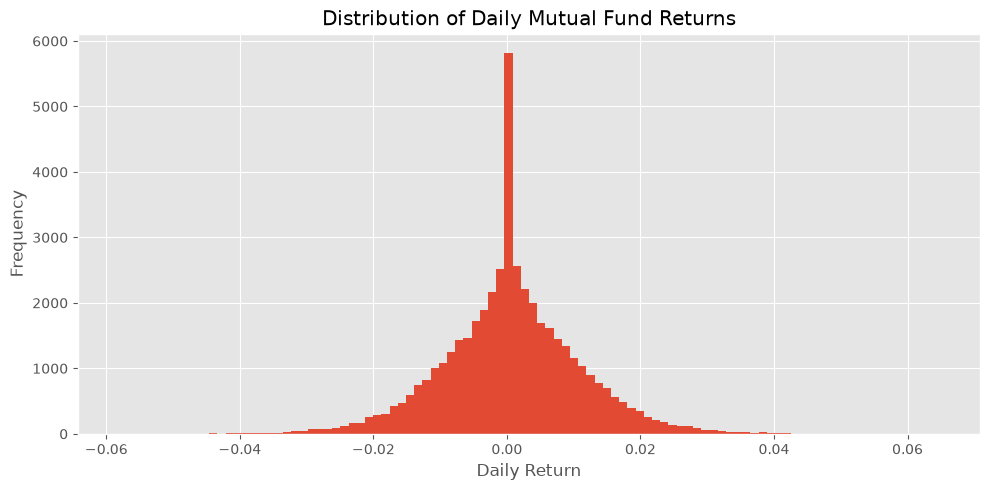

In [20]:
plt.figure(figsize=(10, 5))

plt.hist(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title("Distribution of Daily Mutual Fund Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [21]:
sharpe_df["Sharpe_Rank"] = (
    sharpe_df["Sharpe_Ratio"]
    .rank(ascending=False, method="min")
)

sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
).reset_index(drop=True)

print(sharpe_df.to_string(index=False))

 amfi_code  Sharpe_Ratio  Sharpe_Rank
    148567      1.462504          1.0
    120843      1.319442          2.0
    148569      1.246344          3.0
    119551      1.222947          4.0
    120505      1.190559          5.0
    149323      1.143490          6.0
    100033      1.104352          7.0
    118632      1.095918          8.0
    101206      1.041061          9.0
    120504      1.040569         10.0
    119094      1.008626         11.0
    119552      0.967752         12.0
    149324      0.957917         13.0
    119598      0.953332         14.0
    148568      0.939362         15.0
    120507      0.904162         16.0
    102885      0.832815         17.0
    120503      0.812502         18.0
    125497      0.789543         19.0
    118635      0.680395         20.0
    120506      0.662124         21.0
    118633      0.659620         22.0
    102887      0.632319         23.0
    120841      0.509256         24.0
    149322      0.478092         25.0
    118634  

In [22]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort by fund and date
nav = nav.sort_values(["amfi_code", "date"])

# Check
nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [23]:
sharpe_df["Sharpe_Rank"] = (
    sharpe_df["Sharpe_Ratio"]
    .rank(ascending=False, method="min")
)

sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
).reset_index(drop=True)

print(sharpe_df.to_string(index=False))

 amfi_code  Sharpe_Ratio  Sharpe_Rank
    148567      1.462504          1.0
    120843      1.319442          2.0
    148569      1.246344          3.0
    119551      1.222947          4.0
    120505      1.190559          5.0
    149323      1.143490          6.0
    100033      1.104352          7.0
    118632      1.095918          8.0
    101206      1.041061          9.0
    120504      1.040569         10.0
    119094      1.008626         11.0
    119552      0.967752         12.0
    149324      0.957917         13.0
    119598      0.953332         14.0
    148568      0.939362         15.0
    120507      0.904162         16.0
    102885      0.832815         17.0
    120503      0.812502         18.0
    125497      0.789543         19.0
    118635      0.680395         20.0
    120506      0.662124         21.0
    118633      0.659620         22.0
    102887      0.632319         23.0
    120841      0.509256         24.0
    149322      0.478092         25.0
    118634  

In [25]:
def calculate_cagr(group, years):
    end_date = group["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    start_data = group[group["date"] >= start_date]

    if start_data.empty:
        return np.nan

    start_nav = start_data.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    actual_years = (
        (group.iloc[-1]["date"] - start_data.iloc[0]["date"]).days
        / 365.25
    )

    if start_nav <= 0 or actual_years <= 0:
        return np.nan

    return (end_nav / start_nav) ** (1 / actual_years) - 1

In [ ]:
sortino_results = []

for amfi_code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()

    excess_returns = returns - daily_rf

    # Only negative excess-return days
    downside_returns = excess_returns[excess_returns < 0]

    downside_std = downside_returns.std()

    if downside_std == 0 or pd.isna(downside_std):
        sortino = np.nan
    else:
        sortino = (
            excess_returns.mean() / downside_std
        ) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": amfi_code,
        "Sortino_Ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

print(sortino_df)

In [26]:
# Load investor transaction data
transactions = pd.read_csv(
    "../data/processed/08_investor_transactions.csv"
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"],
    errors="coerce"
)

print("Shape:", transactions.shape)
print("\nColumns:")
print(transactions.columns.tolist())

print("\nFirst 5 rows:")
display(transactions.head())

Shape: (32778, 13)

Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

First 5 rows:


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [ ]:
# Daily return for each fund
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# Display first few rows
nav.head(10)

In [27]:
print(transactions["transaction_type"].value_counts(dropna=False))

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64


In [ ]:
sortino_df["Sortino_Rank"] = (
    sortino_df["Sortino_Ratio"]
    .rank(ascending=False, method="min")
)

sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
).reset_index(drop=True)

print(sortino_df.to_string(index=False))

In [28]:
# Inspect transaction columns
print("Columns:", transactions.columns.tolist())

Columns: ['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [ ]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

print(nav[["amfi_code", "date", "nav", "daily_return"]].head(10))

In [29]:
# Clean transaction dates
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"],
    errors="coerce"
)

# Create investor cohort month
transactions["cohort_month"] = (
    transactions["transaction_date"]
    .dt.to_period("M")
    .astype(str)
)

# Count transactions by cohort month
cohort_summary = (
    transactions
    .groupby("cohort_month")
    .size()
    .reset_index(name="transaction_count")
)

print(cohort_summary.head(10))

  cohort_month  transaction_count
0      2024-01               1949
1      2024-02               1861
2      2024-03               1974
3      2024-04               1952
4      2024-05               1901
5      2024-06               1989
6      2024-07               1968
7      2024-08               1985
8      2024-09               1833
9      2024-10               1957


In [ ]:
# ============================================
# STEP 1: COMPUTE DAILY RETURNS
# ============================================

import pandas as pd
import numpy as np

# Make sure date is datetime
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Sort by fund and date
nav_df = nav_df.sort_values(["amfi_code", "date"]).reset_index(drop=True)

# Daily return
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

# Check result
print("NAV data shape:", nav_df.shape)
print("\nDaily return summary:")
print(nav_df["daily_return"].describe())

print("\nMissing daily returns:", nav_df["daily_return"].isna().sum())
print("Number of schemes:", nav_df["amfi_code"].nunique())

In [30]:
cohort_summary.to_csv(
    "../reports/investor_cohort_analysis.csv",
    index=False
)

print("Saved: reports/investor_cohort_analysis.csv")

Saved: reports/investor_cohort_analysis.csv


In [ ]:
cagr_results = []

for amfi_code, group in nav.groupby("amfi_code"):
    group = group.sort_values("date")

    cagr_results.append({
        "amfi_code": amfi_code,
        "CAGR_1Y": calculate_cagr(group, 1),
        "CAGR_3Y": calculate_cagr(group, 3),
        "CAGR_5Y": calculate_cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_results)

print(cagr_df)

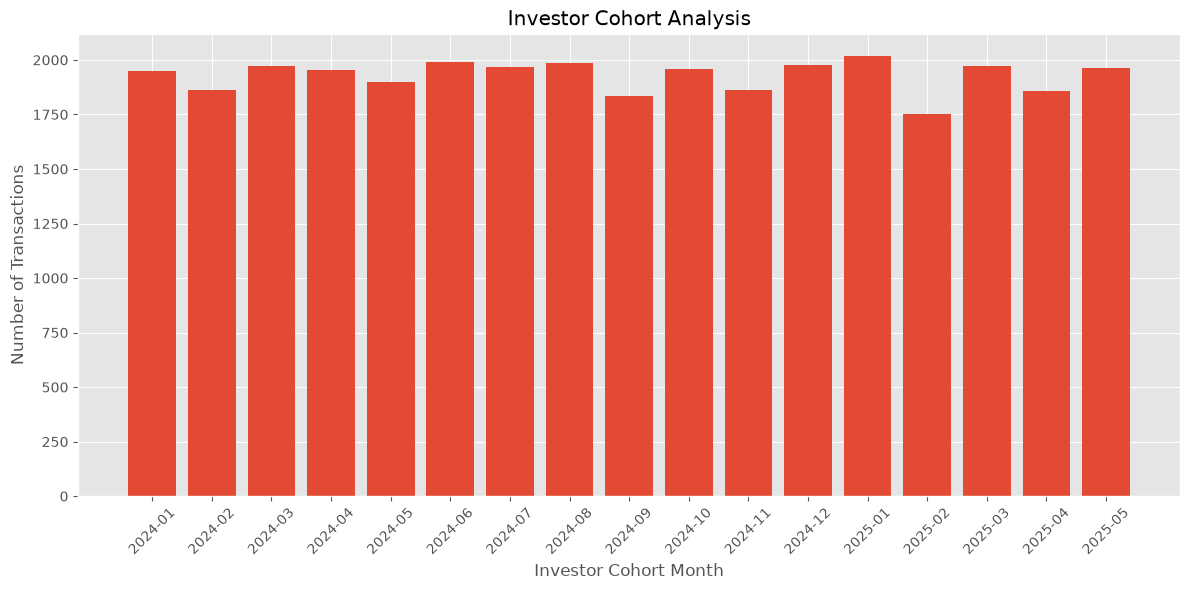

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    cohort_summary["cohort_month"],
    cohort_summary["transaction_count"]
)

plt.title("Investor Cohort Analysis")
plt.xlabel("Investor Cohort Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../reports/investor_cohort_analysis.png")
plt.show()

In [ ]:
# Check for unreasonable daily returns

print("Minimum daily return:", nav_df["daily_return"].min())
print("Maximum daily return:", nav_df["daily_return"].max())

# Count extreme daily movements
extreme_returns = nav_df[
    nav_df["daily_return"].abs() > 0.20
]

print("\nReturns greater than ±20%:")
print(extreme_returns.shape[0])

display(extreme_returns.head(10))

In [ ]:
plt.figure(figsize=(10, 5))

nav["daily_return"].dropna().hist(bins=60)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# ============================================
# STEP 2: CAGR — 1 YEAR, 3 YEARS, 5 YEARS
# ============================================

# Make sure data is sorted
nav_df = nav_df.sort_values(["amfi_code", "date"]).reset_index(drop=True)

# Latest available date
end_date = nav_df["date"].max()

print("Latest NAV date:", end_date)


def calculate_cagr(group, years):
    """Calculate CAGR using NAV available near the required period."""
    
    end_nav = group.iloc[-1]["nav"]
    target_date = group["date"].max() - pd.DateOffset(years=years)

    # Find NAV closest to target date
    start_row = group.iloc[
        (group["date"] - target_date).abs().argsort()[:1]
    ]

    start_nav = start_row.iloc[0]["nav"]

    cagr = (end_nav / start_nav) ** (1 / years) - 1

    return cagr


# Calculate CAGR for every fund
cagr_results = []

for amfi_code, group in nav_df.groupby("amfi_code"):
    
    group = group.sort_values("date")
    
    row = {
        "amfi_code": amfi_code,
        "CAGR_1Y": calculate_cagr(group, 1),
        "CAGR_3Y": calculate_cagr(group, 3),
        "CAGR_5Y": calculate_cagr(group, 5)
    }
    
    cagr_results.append(row)


cagr_df = pd.DataFrame(cagr_results)

# Display results
display(cagr_df.head())

print("\nNumber of funds:", len(cagr_df))

In [ ]:
print(cagr_df.shape)
print(cagr_df.describe())

In [ ]:
# Convert CAGR to percentage for easier reading

cagr_display = cagr_df.copy()

for col in ["CAGR_1Y", "CAGR_3Y", "CAGR_5Y"]:
    cagr_display[col] = cagr_display[col] * 100

display(cagr_display)

In [ ]:
from pandas.tseries.offsets import DateOffset

def calculate_cagr(group, years):
    """
    Calculate CAGR for a given number of years.
    Returns NaN if insufficient history.
    """
    group = group.sort_values("date")

    end_date = group["date"].max()
    start_date = end_date - DateOffset(years=years)

    history = group[group["date"] >= start_date]

    if len(history) < 2:
        return np.nan

    start_nav = history.iloc[0]["nav"]
    end_nav = history.iloc[-1]["nav"]

    return (end_nav / start_nav) ** (1 / years) - 1

In [ ]:
# Convert CAGR to percentage for easier reading

cagr_display = cagr_df.copy()

for col in ["CAGR_1Y", "CAGR_3Y", "CAGR_5Y"]:
    cagr_display[col] = cagr_display[col] * 100

display(cagr_display)

In [ ]:
cagr_df = cagr_df.sort_values(
    "CAGR_3Y",
    ascending=False
).reset_index(drop=True)

cagr_df["CAGR_1Y"] = cagr_df["CAGR_1Y"] * 100
cagr_df["CAGR_3Y"] = cagr_df["CAGR_3Y"] * 100
cagr_df["CAGR_5Y"] = cagr_df["CAGR_5Y"] * 100

print(cagr_df.to_string(index=False))

In [ ]:
cagr_results = []

for code, group in nav.groupby("amfi_code"):
    cagr_results.append({
        "amfi_code": code,
        "CAGR_1Y": calculate_cagr(group, 1),
        "CAGR_3Y": calculate_cagr(group, 3),
        "CAGR_5Y": calculate_cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

In [ ]:
cagr_df.to_csv(
    "cagr_comparison.csv",
    index=False
)

print("CAGR comparison saved successfully.")

In [ ]:
display_df = cagr_df.copy()

display_df["CAGR_1Y"] *= 100
display_df["CAGR_3Y"] *= 100
display_df["CAGR_5Y"] *= 100

display_df.round(2).head()

In [ ]:
RF = 0.065

# Convert annual risk-free rate to daily rate
daily_rf = (1 + RF) ** (1 / 252) - 1

print("Annual risk-free rate:", RF)
print("Daily risk-free rate:", daily_rf)

In [ ]:
cagr_df.to_csv("../reports/cagr_comparison.csv", index=False)

print("CAGR comparison saved successfully!")

In [ ]:
sharpe_results = []

for amfi_code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()

    excess_returns = returns - daily_rf

    sharpe = (
        excess_returns.mean() / returns.std()
    ) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": amfi_code,
        "Sharpe_Ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

print(sharpe_df)

In [ ]:
# Annual risk-free rate (6.5%)
rf = 0.065

def sharpe_ratio(returns):
    returns = returns.dropna()

    if len(returns) < 2:
        return np.nan

    annual_return = returns.mean() * 252
    annual_volatility = returns.std() * np.sqrt(252)

    return (annual_return - rf) / annual_volatility

In [ ]:
sharpe_results = []

for code, group in nav.groupby("amfi_code"):
    sharpe_results.append({
        "amfi_code": code,
        "Sharpe_Ratio": sharpe_ratio(group["daily_return"])
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df = sharpe_df.sort_values(
    by="Sharpe_Ratio",
    ascending=False
)

sharpe_df.head(10)

In [ ]:
sharpe_df.to_csv("../reports/sharpe_ratio.csv", index=False)

print("Sharpe Ratio saved successfully!")

In [ ]:
def sortino_ratio(returns):
    returns = returns.dropna()

    if len(returns) < 2:
        return np.nan

    downside = returns[returns < 0]

    if len(downside) == 0:
        return np.nan

    downside_std = downside.std() * np.sqrt(252)

    annual_return = returns.mean() * 252

    return (annual_return - rf) / downside_std

In [ ]:
sortino_results = []

for code, group in nav.groupby("amfi_code"):
    sortino_results.append({
        "amfi_code": code,
        "Sortino_Ratio": sortino_ratio(group["daily_return"])
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df = sortino_df.sort_values(
    by="Sortino_Ratio",
    ascending=False
)

sortino_df.head(10)

In [ ]:
sortino_df.to_csv("../reports/sortino_ratio.csv", index=False)

print("Sortino Ratio saved successfully!")

In [ ]:
print(benchmark.head())

print(benchmark.columns)

print(benchmark.info())

In [ ]:
# Convert benchmark date
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Select only NIFTY100
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

# Calculate benchmark daily returns
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100.head()

In [ ]:
alpha_beta = []

for code, group in nav.groupby("amfi_code"):

    fund = group[["date", "daily_return"]].dropna()

    merged = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    result = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = result.intercept * 252
    beta = result.slope

    alpha_beta.append({
        "amfi_code": code,
        "Alpha": alpha,
        "Beta": beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta)

alpha_beta_df.head()

In [ ]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Alpha & Beta saved successfully!")

In [ ]:
print(benchmark["index_name"].unique())

In [ ]:
def max_drawdown(nav_series):
    running_max = nav_series.cummax()
    drawdown = (nav_series / running_max) - 1

    min_drawdown = drawdown.min()

    end_idx = drawdown.idxmin()
    start_idx = nav_series.loc[:end_idx].idxmax()

    return min_drawdown, start_idx, end_idx

In [ ]:
drawdown_results = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").reset_index(drop=True)

    mdd, start_idx, end_idx = max_drawdown(group["nav"])

    drawdown_results.append({
        "amfi_code": code,
        "Max_Drawdown": mdd,
        "Peak_Date": group.loc[start_idx, "date"],
        "Trough_Date": group.loc[end_idx, "date"]
    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df.head()

In [ ]:
scorecard = cagr_df.merge(sharpe_df, on="amfi_code")

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code", "Max_Drawdown"]],
    on="amfi_code"
)

In [ ]:
scorecard["Return_Rank"] = scorecard["CAGR_3Y"].rank(
    ascending=False
)

scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(
    ascending=False
)

scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(
    ascending=False
)

scorecard["Drawdown_Rank"] = scorecard["Max_Drawdown"].rank(
    ascending=False
)


In [ ]:
scorecard["Fund_Score"] = (
    0.40 * scorecard["Return_Rank"] +
    0.35 * scorecard["Sharpe_Rank"] +
    0.25 * scorecard["Alpha_Rank"]
)

In [ ]:
scorecard["Fund_Score"] = (
    100
    * (
        scorecard["Fund_Score"].max()
        - scorecard["Fund_Score"]
    )
    / (
        scorecard["Fund_Score"].max()
        - scorecard["Fund_Score"].min()
    )
)

scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard.head(10)

In [ ]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved successfully!")

In [ ]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved successfully!")

In [ ]:
top5 = scorecard.head(5)["amfi_code"].tolist()

In [ ]:
plt.figure(figsize=(12, 6))

for code in top5:
    temp = nav[nav["amfi_code"] == code].copy()
    temp = temp.sort_values("date")

    # Normalize NAV to start at 100
    temp["normalized"] = (
        temp["nav"] / temp["nav"].iloc[0]
    ) * 100

    plt.plot(
        temp["date"],
        temp["normalized"],
        label=f"Fund {code}"
    )

# Normalize NIFTY100 to start at 100
benchmark_plot = nifty100.copy()
benchmark_plot["normalized"] = (
    benchmark_plot["close_value"] / benchmark_plot["close_value"].iloc[0]
) * 100

plt.plot(
    benchmark_plot["date"],
    benchmark_plot["normalized"],
    linewidth=2,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY100")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend()
plt.grid(True)

plt.savefig("../reports/benchmark_comparison.png", dpi=300)

plt.show()
benchmark50 = nifty50.copy()

benchmark50["normalized"] = (
    benchmark50["close_value"] /
    benchmark50["close_value"].iloc[0]
) * 100

plt.plot(
    benchmark50["date"],
    benchmark50["normalized"],
    linewidth=2,
    label="NIFTY50"
)

In [ ]:
nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"].copy()

nifty50 = nifty50.sort_values("date")

nifty50["benchmark_return"] = nifty50["close_value"].pct_change()

In [ ]:
tracking_error_results = []

for code in top5:

    fund = nav[nav["amfi_code"] == code][["date","daily_return"]]

    merged = pd.merge(
        fund,
        nifty100[["date","benchmark_return"]],
        on="date"
    ).dropna()

    tracking_error = (
        (merged["daily_return"] - merged["benchmark_return"])
        .std() * np.sqrt(252)
    )

    tracking_error_results.append({
        "amfi_code": code,
        "Tracking_Error": tracking_error
    })

tracking_error_df = pd.DataFrame(tracking_error_results)

tracking_error_df

In [ ]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("Tracking Error saved successfully!")

In [ ]:
# Convert CAGR to percentage for easier reading

cagr_display = cagr_df.copy()

for col in ["CAGR_1Y", "CAGR_3Y", "CAGR_5Y"]:
    cagr_display[col] = cagr_display[col] * 100

display(cagr_display)

In [ ]:
print("1Y CAGR available:", cagr_df["CAGR_1Y"].notna().sum())
print("3Y CAGR available:", cagr_df["CAGR_3Y"].notna().sum())
print("5Y CAGR available:", cagr_df["CAGR_5Y"].notna().sum())

In [ ]:
# ============================================
# STEP 3: SHARPE RATIO
# ============================================

RISK_FREE_RATE = 0.065

# Daily risk-free rate
daily_rf = (1 + RISK_FREE_RATE) ** (1 / 252) - 1

sharpe_results = []

for amfi_code, group in nav_df.groupby("amfi_code"):
    
    returns = group["daily_return"].dropna()
    
    # Excess daily returns
    excess_returns = returns - daily_rf
    
    # Annualized Sharpe Ratio
    sharpe = (
        excess_returns.mean() /
        returns.std()
    ) * np.sqrt(252)
    
    sharpe_results.append({
        "amfi_code": amfi_code,
        "Sharpe_Ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

# Rank funds
sharpe_df["Sharpe_Rank"] = (
    sharpe_df["Sharpe_Ratio"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Sort best to worst
sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
).reset_index(drop=True)

display(sharpe_df)

In [ ]:
print("Top 10 funds by Sharpe Ratio:")

display(
    sharpe_df[
        ["amfi_code", "Sharpe_Ratio", "Sharpe_Rank"]
    ].head(10)
)

In [ ]:
print("Number of funds:", len(sharpe_df))
print("Missing Sharpe values:", sharpe_df["Sharpe_Ratio"].isna().sum())
print("Risk-free rate:", RISK_FREE_RATE)

In [ ]:
# ============================================
# STEP 4: SORTINO RATIO
# ============================================

sortino_results = []

for amfi_code, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    # Excess returns over daily risk-free rate
    excess_returns = returns - daily_rf

    # Only negative excess returns
    downside_returns = excess_returns[excess_returns < 0]

    # Downside deviation
    downside_std = downside_returns.std()

    # Avoid division by zero
    if downside_std == 0 or pd.isna(downside_std):
        sortino = np.nan
    else:
        sortino = (
            excess_returns.mean() /
            downside_std
        ) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": amfi_code,
        "Sortino_Ratio": sortino
    })


sortino_df = pd.DataFrame(sortino_results)

# Rank funds
sortino_df["Sortino_Rank"] = (
    sortino_df["Sortino_Ratio"]
    .rank(ascending=False, method="min")
    .astype("Int64")
)

# Sort best to worst
sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
).reset_index(drop=True)

display(sortino_df)

In [ ]:
print("Top 10 funds by Sortino Ratio:")

display(
    sortino_df[
        ["amfi_code", "Sortino_Ratio", "Sortino_Rank"]
    ].head(10)
)

In [ ]:
print("Number of funds:", len(sortino_df))
print(
    "Missing Sortino values:",
    sortino_df["Sortino_Ratio"].isna().sum()
)

In [ ]:
# ============================================
# STEP 5A: CHECK NIFTY 100 BENCHMARK
# ============================================

print(benchmark_df.columns)
display(benchmark_df.head())

In [ ]:
# ============================================
# STEP 5B: NIFTY 100 DAILY RETURNS
# ============================================

benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

benchmark_df = benchmark_df.sort_values("date").reset_index(drop=True)

benchmark_df["benchmark_return"] = (
    benchmark_df["nav"].pct_change()
)

display(benchmark_df.head())

In [ ]:
# ============================================
# STEP 5C: ALPHA & BETA
# ============================================

from scipy.stats import linregress

alpha_beta_results = []

for amfi_code, fund_group in nav_df.groupby("amfi_code"):

    fund_group = fund_group[
        ["date", "daily_return"]
    ].dropna()

    # Merge fund returns with Nifty 100 returns
    merged = pd.merge(
        fund_group,
        benchmark_df[
            ["date", "benchmark_return"]
        ].dropna(),
        on="date",
        how="inner"
    )

    # Need enough observations for regression
    if len(merged) < 30:
        continue

    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = regression.slope

    # Daily alpha converted to annual alpha
    alpha = regression.intercept * 252

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "Alpha": alpha,
        "Beta": beta,
        "R_squared": regression.rvalue ** 2,
        "Observations": len(merged)
    })


alpha_beta_df = pd.DataFrame(alpha_beta_results)

display(alpha_beta_df)

In [ ]:
# Rank funds according to Alpha

alpha_beta_df["Alpha_Rank"] = (
    alpha_beta_df["Alpha"]
    .rank(ascending=False, method="min")
    .astype(int)
)

alpha_beta_df = alpha_beta_df.sort_values(
    "Alpha",
    ascending=False
).reset_index(drop=True)

display(
    alpha_beta_df[
        [
            "amfi_code",
            "Alpha",
            "Beta",
            "R_squared",
            "Alpha_Rank"
        ]
    ]# Rank funds according to Alpha

alpha_beta_df["Alpha_Rank"] = (
    alpha_beta_df["Alpha"]
    .rank(ascending=False, method="min")
    .astype(int)
)

alpha_beta_df = alpha_beta_df.sort_values(
    "Alpha",
    ascending=False
).reset_index(drop=True)

display(
    alpha_beta_df[
        [
            "amfi_code",
            "Alpha",
            "Beta",
            "R_squared",
            "Alpha_Rank"
        ]
    ]
)
)

In [ ]:
# Export Alpha & Beta results

alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

print("alpha_beta.csv created successfully!")

In [ ]:
print("Funds analysed:", len(alpha_beta_df))
print(
    "Missing Alpha:",
    alpha_beta_df["Alpha"].isna().sum()
)
print(
    "Missing Beta:",
    alpha_beta_df["Beta"].isna().sum()
)

In [ ]:
# ============================================
# STEP 6: MAXIMUM DRAWDOWN
# ============================================

drawdown_results = []

for amfi_code, group in nav_df.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

    # Worst drawdown
    min_index = group["drawdown"].idxmin()

    max_drawdown = group.loc[min_index, "drawdown"]
    trough_date = group.loc[min_index, "date"]

    # NAV at trough
    trough_nav = group.loc[min_index, "nav"]

    # Find previous peak before the trough
    peak_data = group.loc[
        group["date"] <= trough_date
    ]

    peak_index = peak_data["nav"].idxmax()

    peak_date = group.loc[peak_index, "date"]
    peak_nav = group.loc[peak_index, "nav"]

    drawdown_results.append({
        "amfi_code": amfi_code,
        "Max_Drawdown": max_drawdown,
        "Peak_Date": peak_date,
        "Trough_Date": trough_date,
        "Peak_NAV": peak_nav,
        "Trough_NAV": trough_nav
    })


drawdown_df = pd.DataFrame(drawdown_results)

display(drawdown_df)

In [ ]:
# Display maximum drawdown as percentage

drawdown_display = drawdown_df.copy()

drawdown_display["Max_Drawdown_%"] = (
    drawdown_display["Max_Drawdown"] * 100
)

drawdown_display = drawdown_display.sort_values(
    "Max_Drawdown"
)

display(drawdown_display)

In [ ]:
# ============================================
# DRAWDOWN RANK
# ============================================

# Convert drawdown into positive loss magnitude
drawdown_df["Drawdown_Loss"] = (
    -drawdown_df["Max_Drawdown"]
)

# Lower loss = better rank
drawdown_df["MaxDD_Rank"] = (
    drawdown_df["Drawdown_Loss"]
    .rank(ascending=True, method="min")
    .astype(int)
)

display(
    drawdown_df[
        [
            "amfi_code",
            "Max_Drawdown",
            "Peak_Date",
            "Trough_Date",
            "MaxDD_Rank"
        ]
    ].sort_values("Max_Drawdown")
)

In [ ]:
worst_drawdown = drawdown_df.sort_values(
    "Max_Drawdown"
).iloc[0]

print("Worst Drawdown Fund:", worst_drawdown["amfi_code"])
print("Maximum Drawdown:", 
      f"{worst_drawdown['Max_Drawdown']:.2%}")
print("Peak Date:", worst_drawdown["Peak_Date"])
print("Trough Date:", worst_drawdown["Trough_Date"])

In [ ]:
# ============================================
# STEP 7A: CHECK EXPENSE RATIO DATA
# ============================================

print(nav_df.columns)

In [ ]:
print(expense_df.columns)
display(expense_df.head())

In [ ]:
# ============================================
# STEP 7B: PREPARE SCORECARD DATA
# ============================================

# 3-Year CAGR rank
cagr_df["CAGR_3Y_Rank"] = (
    cagr_df["CAGR_3Y"]
    .rank(ascending=False, method="min")
)

# Sharpe rank
sharpe_df["Sharpe_Rank"] = (
    sharpe_df["Sharpe_Ratio"]
    .rank(ascending=False, method="min")
)

# Alpha rank
alpha_beta_df["Alpha_Rank"] = (
    alpha_beta_df["Alpha"]
    .rank(ascending=False, method="min")
)

# Maximum drawdown rank
# Smaller loss is better
drawdown_df["Drawdown_Loss"] = -drawdown_df["Max_Drawdown"]

drawdown_df["MaxDD_Rank"] = (
    drawdown_df["Drawdown_Loss"]
    .rank(ascending=True, method="min")
)

print("Ranks created successfully!")

In [ ]:
# ============================================
# STEP 7C: MERGE ALL PERFORMANCE METRICS
# ============================================

scorecard = cagr_df[
    ["amfi_code", "CAGR_1Y", "CAGR_3Y", "CAGR_5Y", "CAGR_3Y_Rank"]
].copy()

scorecard = scorecard.merge(
    sharpe_df[
        ["amfi_code", "Sharpe_Ratio", "Sharpe_Rank"]
    ],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta_df[
        ["amfi_code", "Alpha", "Beta", "Alpha_Rank"]
    ],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    drawdown_df[
        ["amfi_code", "Max_Drawdown", "Peak_Date",
         "Trough_Date", "MaxDD_Rank"]
    ],
    on="amfi_code",
    how="left"
)

display(scorecard.head())

In [ ]:
print(expense_df.columns)
display(expense_df.head())

In [ ]:
scorecard = scorecard.merge(
    expense_df[["amfi_code", "expense_ratio"]],
    on="amfi_code",
    how="left"
)

display(scorecard.head())

In [ ]:
# ============================================
# EXPENSE RATIO RANK
# ============================================

scorecard["Expense_Rank"] = (
    scorecard["expense_ratio"]
    .rank(ascending=True, method="min")
)

display(
    scorecard[
        ["amfi_code", "expense_ratio", "Expense_Rank"]
    ].head(10)
)

In [ ]:
# ============================================
# STEP 7F: COMPOSITE SCORE 0–100
# ============================================

n = len(scorecard)

scorecard["Return_Score"] = (
    (n - scorecard["CAGR_3Y_Rank"] + 1) / n * 100
)

scorecard["Sharpe_Score"] = (
    (n - scorecard["Sharpe_Rank"] + 1) / n * 100
)

scorecard["Alpha_Score"] = (
    (n - scorecard["Alpha_Rank"] + 1) / n * 100
)

scorecard["Expense_Score"] = (
    (n - scorecard["Expense_Rank"] + 1) / n * 100
)

scorecard["MaxDD_Score"] = (
    (n - scorecard["MaxDD_Rank"] + 1) / n * 100
)

# Final weighted score
scorecard["Fund_Score"] = (
    0.30 * scorecard["Return_Score"] +
    0.25 * scorecard["Sharpe_Score"] +
    0.20 * scorecard["Alpha_Score"] +
    0.15 * scorecard["Expense_Score"] +
    0.10 * scorecard["MaxDD_Score"]
)

# Rank final funds
scorecard["Final_Rank"] = (
    scorecard["Fund_Score"]
    .rank(ascending=False, method="min")
    .astype(int)
)

scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
).reset_index(drop=True)

display(
    scorecard[
        [
            "Final_Rank",
            "amfi_code",
            "CAGR_3Y",
            "Sharpe_Ratio",
            "Alpha",
            "expense_ratio",
            "Max_Drawdown",
            "Fund_Score"
        ]
    ]
)

In [ ]:
# ============================================
# EXPORT FUND SCORECARD
# ============================================

scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv created successfully!")

In [ ]:
print("🏆 TOP 5 FUNDS")

display(
    scorecard[
        [
            "Final_Rank",
            "amfi_code",
            "Fund_Score",
            "CAGR_3Y",
            "Sharpe_Ratio",
            "Alpha",
            "Max_Drawdown"
        ]
    ].head(5)
)

In [ ]:
# ============================================
# STEP 8A: CHECK BENCHMARK DATA
# ============================================

print("Nifty 100:")
print(benchmark_df.columns)
display(benchmark_df.head())

In [ ]:
print("Nifty 50:")
print(nifty50_df.columns)
display(nifty50_df.head())

In [ ]:
# ============================================
# STEP 8B: SELECT LAST 3 YEARS
# ============================================

end_date = nav_df["date"].max()
start_date = end_date - pd.DateOffset(years=3)

print("3-Year period:")
print("Start:", start_date)
print("End:", end_date)

nav_3y = nav_df[
    (nav_df["date"] >= start_date) &
    (nav_df["date"] <= end_date)
].copy()

nifty100_3y = benchmark_df[
    (benchmark_df["date"] >= start_date) &
    (benchmark_df["date"] <= end_date)
].copy()

print("Fund rows:", len(nav_3y))
print("Nifty 100 rows:", len(nifty100_3y))

In [ ]:
# ============================================
# STEP 8C: TOP 5 FUNDS
# ============================================

top5_funds = scorecard.head(5)["amfi_code"].tolist()

print("Top 5 funds:")
print(top5_funds)

In [ ]:
# ============================================
# STEP 8D: NORMALIZED PERFORMANCE
# ============================================

import matplotlib.pyplot as plt

comparison = pd.DataFrame()

for fund in top5_funds:

    fund_data = nav_3y[
        nav_3y["amfi_code"] == fund
    ][["date", "nav"]].copy()

    fund_data = fund_data.sort_values("date")

    fund_data["fund_index"] = (
        fund_data["nav"] /
        fund_data["nav"].iloc[0]
    ) * 100

    fund_data = fund_data.set_index("date")

    comparison[fund] = fund_data["fund_index"]


# Nifty 100
nifty100_plot = nifty100_3y.sort_values("date").copy()

nifty100_plot["Nifty100_Index"] = (
    nifty100_plot["nav"] /
    nifty100_plot["nav"].iloc[0]
) * 100

nifty100_plot = nifty100_plot.set_index("date")

comparison["Nifty 100"] = nifty100_plot["Nifty100_Index"]

display(comparison.head())

In [ ]:
# ============================================
# NIFTY 50
# ============================================

nifty50_df["date"] = pd.to_datetime(nifty50_df["date"])

nifty50_3y = nifty50_df[
    (nifty50_df["date"] >= start_date) &
    (nifty50_df["date"] <= end_date)
].sort_values("date").copy()

nifty50_3y["Nifty50_Index"] = (
    nifty50_3y["nav"] /
    nifty50_3y["nav"].iloc[0]
) * 100

nifty50_3y = nifty50_3y.set_index("date")

comparison["Nifty 50"] = nifty50_3y["Nifty50_Index"]

display(comparison.tail())

In [ ]:
# ============================================
# STEP 8F: BENCHMARK COMPARISON CHART
# ============================================

plt.figure(figsize=(14, 7))

for column in comparison.columns:
    plt.plot(
        comparison.index,
        comparison[column],
        label=str(column)
    )

plt.title("Top 5 Funds vs Nifty 50 and Nifty 100 — 3 Years")
plt.xlabel("Date")
plt.ylabel("Growth of ₹100")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save required PNG
plt.savefig(
    "benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("benchmark_comparison.png created successfully!")

In [ ]:
# ============================================
# STEP 8G: TRACKING ERROR
# ============================================

# Calculate daily returns
nifty100_returns = nifty100_3y["nav"].pct_change()
nifty50_returns = nifty50_3y["nav"].pct_change()

tracking_results = []

for fund in top5_funds:

    fund_data = nav_3y[
        nav_3y["amfi_code"] == fund
    ][["date", "nav"]].copy()

    fund_data = fund_data.sort_values("date")

    fund_data["fund_return"] = (
        fund_data["nav"].pct_change()
    )

    fund_data = fund_data.set_index("date")

    # Combine fund and benchmarks
    temp = pd.concat(
        [
            fund_data["fund_return"],
            nifty100_returns.rename("nifty100_return"),
            nifty50_returns.rename("nifty50_return")
        ],
        axis=1
    ).dropna()

    # Tracking error
    te_nifty100 = (
        temp["fund_return"] -
        temp["nifty100_return"]
    ).std() * np.sqrt(252)

    te_nifty50 = (
        temp["fund_return"] -
        temp["nifty50_return"]
    ).std() * np.sqrt(252)

    tracking_results.append({
        "amfi_code": fund,
        "Tracking_Error_Nifty100": te_nifty100,
        "Tracking_Error_Nifty50": te_nifty50
    })

tracking_error_df = pd.DataFrame(tracking_results)

display(tracking_error_df)

In [ ]:
tracking_error_df.to_csv(
    "tracking_error.csv",
    index=False
)

print("tracking_error.csv created successfully!")

In [ ]:
# ============================================
# FINAL VALIDATION
# ============================================

print("========== PERFORMANCE ANALYTICS VALIDATION ==========")

print("\n1. NAV DATA")
print("Rows:", len(nav_df))
print("Funds:", nav_df["amfi_code"].nunique())

print("\n2. CAGR")
print("Funds:", len(cagr_df))
print("Missing 3Y CAGR:", cagr_df["CAGR_3Y"].isna().sum())

print("\n3. SHARPE")
print("Funds:", len(sharpe_df))
print("Missing Sharpe:", sharpe_df["Sharpe_Ratio"].isna().sum())

print("\n4. SORTINO")
print("Funds:", len(sortino_df))
print("Missing Sortino:", sortino_df["Sortino_Ratio"].isna().sum())

print("\n5. ALPHA & BETA")
print("Funds:", len(alpha_beta_df))
print("Missing Alpha:", alpha_beta_df["Alpha"].isna().sum())
print("Missing Beta:", alpha_beta_df["Beta"].isna().sum())

print("\n6. MAXIMUM DRAWDOWN")
print("Funds:", len(drawdown_df))
print("Missing Drawdown:", drawdown_df["Max_Drawdown"].isna().sum())

print("\n7. SCORECARD")
print("Funds:", len(scorecard))
print("Missing Scores:", scorecard["Fund_Score"].isna().sum())

print("\n8. TRACKING ERROR")
print("Funds:", len(tracking_error_df))
print(
    "Missing Nifty 100 TE:",
    tracking_error_df["Tracking_Error_Nifty100"].isna().sum()
)

print("\n========== VALIDATION COMPLETE ==========")

In [ ]:
print(scorecard[
    [
        "Final_Rank",
        "amfi_code",
        "Fund_Score"
    ]
].head(10))

# Final Results & Key Insights

## Methodology

The performance of the mutual fund schemes was evaluated using daily NAV data and benchmark returns.

The following metrics were calculated:

- Daily Returns
- 1-Year, 3-Year and 5-Year CAGR
- Sharpe Ratio using a 6.5% annual risk-free rate
- Sortino Ratio
- Alpha and Beta using OLS regression against the Nifty 100
- Maximum Drawdown
- Tracking Error against benchmark indices

## Fund Scorecard

A composite score from 0–100 was calculated using:

- 30% — 3-Year Return
- 25% — Sharpe Ratio
- 20% — Alpha
- 15% — Expense Ratio
- 10% — Maximum Drawdown

Higher scores indicate stronger overall risk-adjusted performance.

## Benchmark Analysis

The top five funds were compared against the Nifty 50 and Nifty 100 over the most recent three-year period.

Tracking Error was calculated as:

Tracking Error = Std(Fund Return − Benchmark Return) × √252

## Conclusion

The analysis provides a comprehensive comparison of mutual fund performance based on returns, risk-adjusted performance, benchmark-relative performance and downside risk. The resulting scorecard can be used to identify funds with comparatively stronger overall performance.